# 04. 학습

03에서 설계한 LoRA 아키텍처로 실제 파인튜닝을 수행한다. `(noisy_query, 정답 passage)` 쌍에
`MultipleNegativesRankingLoss`(배치 내 다른 passage를 negative로 사용)를 적용한다.

**CPU 실행 제약**: 데이터 규모(816 train쌍)와 CPU 학습 시간을 고려해 epoch 수를 3으로,
`max_seq_length`를 512로 제한했다. 더 큰 규모로 학습하려면 GPU 환경과 더 많은 코퍼스가 필요하다.

산출물: `document_고무서/output/embedding-finetune/04_training/`

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from peft import LoraConfig, get_peft_model
import torch

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {DEVICE}")

from sentence_transformers import InputExample, SentenceTransformer, losses, util
from torch.utils.data import DataLoader

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

PROCESSED_DIR = Path("../output/embedding-finetune/02_preprocessing/processed")
MODELING_DIR = Path("../output/embedding-finetune/03_modeling")
OUTPUT_DIR = Path("../output/embedding-finetune/04_training")
MODEL_DIR = OUTPUT_DIR / "model"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

corpus_df = pd.read_csv(PROCESSED_DIR / "corpus.csv")
train_df = pd.read_csv(PROCESSED_DIR / "train_pairs.csv")
eval_df = pd.read_csv(PROCESSED_DIR / "eval_pairs.csv")

with open(MODELING_DIR / "baseline_metrics.json", encoding="utf-8") as f:
    baseline_metrics = json.load(f)

print(f"train 쌍: {len(train_df)}, eval 쌍: {len(eval_df)}, corpus: {len(corpus_df)}")

/Users/gomuseo/Desktop/Python/Work-Flow/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/gomuseo/Desktop/Python/Work-Flow/.venv/lib/python3.12/site-packages/torchao/quantization/quant_api.py:1745: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.
W0721 21:32:37.721000 75520 torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.
W0721 21:32:37.814000 75520 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0721 21:32:37.901000 75520 torch/utils/_p

사용 디바이스: mps
train 쌍: 816, eval 쌍: 208, corpus: 128


/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_75520/4152993113.py:12: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import InputExample, SentenceTransformer, losses, util


## 1. 모델 및 LoRA 아키텍처 준비 (03과 동일 설정)

In [2]:
MODEL_NAME = "BAAI/bge-m3"
MAX_SEQ_LENGTH = 512
EPOCHS = 3

model = SentenceTransformer(MODEL_NAME, token=False, device=DEVICE)
model.max_seq_length = MAX_SEQ_LENGTH

# sentence-transformers 5.x 내장 PEFT 지원(add_adapter)을 사용한다. model[0].auto_model에
# get_peft_model() 결과를 수동으로 재할당하는 방식은 이 버전에서 auto_model이 프로퍼티로
# 노출되어 있어 재할당이 반영되지 않는다(03_modeling.ipynb에서 확인).
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["query", "key", "value"],
    bias="none",
)
model.add_adapter(lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"학습 대상 파라미터: {trainable_params:,} / 전체: {total_params:,} ({100 * trainable_params / total_params:.4f}%)")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 21819.18it/s]


학습 대상 파라미터: 1,179,648 / 전체: 568,934,400 (0.2073%)


## 2. 학습 데이터 준비

In [3]:
train_examples = [InputExample(texts=[row["noisy_query"], row["content"]]) for _, row in train_df.iterrows()]
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=8)
train_loss = losses.MultipleNegativesRankingLoss(model)

## 3. 학습 실행 및 epoch별 진행 곡선

`sentence-transformers`의 `fit()`은 내부 loss 이력을 직접 노출하지 않으므로,
1 epoch씩 나눠 학습한 뒤 매 epoch 종료 시점마다 eval set(noisy_query)으로 검색 성능을
측정해 "학습이 실제로 개선을 만들고 있는지"를 그래프로 확인한다.

In [4]:
def evaluate_retrieval(model, corpus_df, eval_df, query_column, k_values=(1, 3, 5)):
    corpus_embeddings = model.encode(
        corpus_df["content"].tolist(), convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False
    )
    query_embeddings = model.encode(
        eval_df[query_column].tolist(), convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False
    )
    similarity = util.cos_sim(query_embeddings, corpus_embeddings)
    ranks = similarity.argsort(dim=1, descending=True)

    correct_positions = []
    for row_idx, (_, eval_row) in enumerate(eval_df.iterrows()):
        target_corpus_idx = corpus_df.index[corpus_df["id"] == eval_row["id"]][0]
        rank_list = ranks[row_idx].tolist()
        correct_positions.append(rank_list.index(target_corpus_idx))

    metrics = {f"recall@{k}": sum(p < k for p in correct_positions) / len(correct_positions) for k in k_values}
    metrics["mrr"] = sum(1.0 / (p + 1) for p in correct_positions) / len(correct_positions)
    return metrics


history = [{"epoch": 0, **evaluate_retrieval(model, corpus_df, eval_df, "noisy_query")}]
print("epoch 0 (학습 전):", history[-1])

for epoch in range(1, EPOCHS + 1):
    model.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=1,
        warmup_steps=int(len(train_dataloader) * 0.1),
        show_progress_bar=True,
    )
    epoch_metrics = evaluate_retrieval(model, corpus_df, eval_df, "noisy_query")
    history.append({"epoch": epoch, **epoch_metrics})
    print(f"epoch {epoch}:", epoch_metrics)

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_progress.csv", index=False)
history_df

epoch 0 (학습 전): {'epoch': 0, 'recall@1': 0.7788461538461539, 'recall@3': 1.0, 'recall@5': 1.0, 'mrr': 0.8894230769230769}


/Users/gomuseo/Desktop/Python/Work-Flow/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


epoch 1: {'recall@1': 0.8028846153846154, 'recall@3': 1.0, 'recall@5': 1.0, 'mrr': 0.9014423076923077}


Step,Training Loss


epoch 2: {'recall@1': 0.8221153846153846, 'recall@3': 1.0, 'recall@5': 1.0, 'mrr': 0.9110576923076923}


Step,Training Loss


epoch 3: {'recall@1': 0.8076923076923077, 'recall@3': 1.0, 'recall@5': 1.0, 'mrr': 0.9038461538461539}


,epoch,recall@1,recall@3,recall@5,mrr
0,0,0.778846,1.0,1.0,0.889423
1,1,0.802885,1.0,1.0,0.901442
2,2,0.822115,1.0,1.0,0.911058
3,3,0.807692,1.0,1.0,0.903846


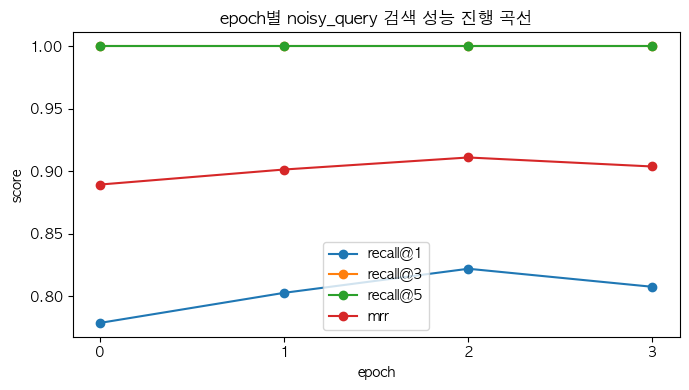

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for metric in ["recall@1", "recall@3", "recall@5", "mrr"]:
    ax.plot(history_df["epoch"], history_df[metric], marker="o", label=metric)
ax.set_xlabel("epoch")
ax.set_ylabel("score")
ax.set_title("epoch별 noisy_query 검색 성능 진행 곡선")
ax.set_xticks(history_df["epoch"])
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_progress.png", dpi=150)
plt.show()

## 4. 모델 저장

학습된 어댑터를 포함한 상태로 저장한다. 평가는 이 저장 과정과 무관하게 학습 직후의
메모리 상 모델로 진행하므로(다음 셀), 저장/재로딩 과정의 문제가 평가 결과에 영향을 주지 않는다.


In [6]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model.save(str(MODEL_DIR))
print(f"학습된 모델(LoRA 어댑터 포함) 저장 완료: {MODEL_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 14.71it/s]


학습된 모델(LoRA 어댑터 포함) 저장 완료: ../output/embedding-finetune/04_training/model


## 5. 최종 비교 평가 (베이스라인 vs 파인튜닝)

In [7]:
finetuned_clean = evaluate_retrieval(model, corpus_df, eval_df, "clean_query")
finetuned_noisy = evaluate_retrieval(model, corpus_df, eval_df, "noisy_query")

final_metrics = {
    "baseline_clean": baseline_metrics["clean"],
    "baseline_noisy": baseline_metrics["noisy"],
    "finetuned_clean": finetuned_clean,
    "finetuned_noisy": finetuned_noisy,
}
with open(OUTPUT_DIR / "final_comparison.json", "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, ensure_ascii=False, indent=2)

final_table = pd.DataFrame(final_metrics).T
final_table.to_csv(OUTPUT_DIR / "final_comparison.csv")
final_table

,recall@1,recall@3,recall@5,mrr
baseline_clean,0.769231,1.0,1.0,0.884615
baseline_noisy,0.778846,1.0,1.0,0.889423
finetuned_clean,0.807692,1.0,1.0,0.903846
finetuned_noisy,0.807692,1.0,1.0,0.903846


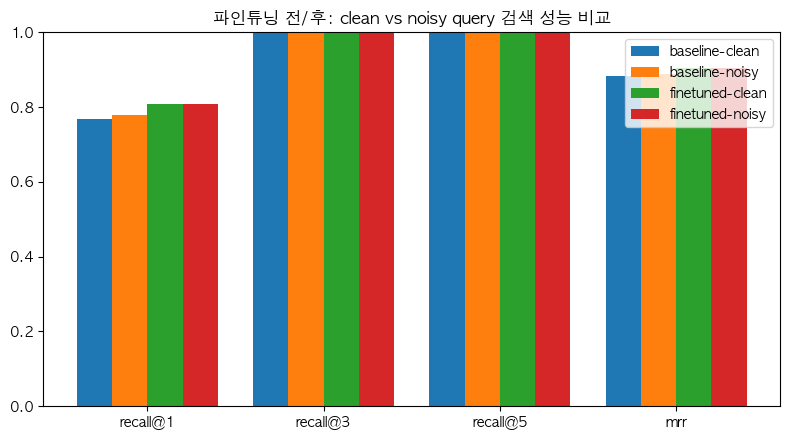

In [8]:
labels = list(finetuned_clean.keys())
x = range(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar([i - 1.5 * width for i in x], [baseline_metrics["clean"][k] for k in labels], width, label="baseline-clean")
ax.bar([i - 0.5 * width for i in x], [baseline_metrics["noisy"][k] for k in labels], width, label="baseline-noisy")
ax.bar([i + 0.5 * width for i in x], [finetuned_clean[k] for k in labels], width, label="finetuned-clean")
ax.bar([i + 1.5 * width for i in x], [finetuned_noisy[k] for k in labels], width, label="finetuned-noisy")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("파인튜닝 전/후: clean vs noisy query 검색 성능 비교")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "final_comparison.png", dpi=150)
plt.show()

## 결론 판단 기준

- `finetuned-noisy`가 `baseline-noisy`보다 확실히 올라가고, `finetuned-clean`과의 격차가
  `baseline-clean` vs `baseline-noisy` 격차보다 좁아졌다면 **파인튜닝이 유효**하다고 판단한다.
- `finetuned-clean`이 `baseline-clean`보다 떨어졌다면 과적합(catastrophic forgetting) 가능성이 있으므로
  LoRA rank(`r`)를 낮추거나 epoch을 줄여 재실행한다.
- 결과는 `docs/trouble-shooting/2026-07-21-rag-noisy-query-embedding-finetune.md`에 기록한다.